# **Automated Customer Churn Prediction System**

**Dataset:** Telco Customer Churn (blastchar/telco-customer-churn, Kaggle)  
**Student:** Roishoiron  
**Purpose:** End-to-End MLOps Pipeline with MLflow, Prometheus, and Grafana

## **1. Import Library**

Mengimpor pustaka Python untuk analisis data, visualisasi, preprocessing, dan model machine learning.

In [21]:
# === Data Manipulation & Analysis ===
import pandas as pd
import numpy as np

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Preprocessing & Scaling ===
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# === Models ===
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# === SMOTE for Imbalanced Data ===
from imblearn.over_sampling import SMOTE

# === MLflow ===
import mlflow
import mlflow.sklearn
import datetime

# === Warnings ===
import warnings
warnings.filterwarnings('ignore')

# === Set Display Options ===
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('whitegrid')

## **2. Data Loading**

Memuat dataset Telco Customer Churn dan memverifikasi struktur data. Dataset ini berisi informasi pelanggan sebuah perusahaan telekomunikasi untuk mendeteksi churn (pelanggan yang berhenti berlangganan).

In [22]:
# Load dataset
df = pd.read_csv('data/wa_customer_churn_total.csv')

print('=' * 60)
print('📊 TELCO CUSTOMER CHURN DATASET')
print('=' * 60)
print(f'\n📐 Shape Dataset: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'📅 Tanggal Eksperimen: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'\n📋 Kolom-kolom:\n{list(df.columns)}')
print('\n' + '=' * 60)

# Tampilkan 5 baris pertama
print('\n📄 Sample Data (5 rows):')
display(df.head())

print('\n' + '=' * 60)

📊 TELCO CUSTOMER CHURN DATASET

📐 Shape Dataset: 7043 rows x 21 columns
📅 Tanggal Eksperimen: 2026-06-02 02:38:53

📋 Kolom-kolom:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


📄 Sample Data (5 rows):


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **3. Exploratory Data Analysis (EDA)**

Melakukan analisis mendalam terhadap karakteristik dataset untuk memahami pola, distribusi, dan hubungan antar fitur sebelum preprocessing.

In [23]:
# === 3.1 Statistical Summary ===
print('\n📈 STATISTICAL SUMMARY:')
display(df.describe().round(2))

print('\n' + '=' * 60)

# === 3.2 Dataset Info ===
print('\nℹ️ DATASET INFO:')
print(df.info())

print('\n' + '=' * 60)

# === 3.3 Missing Values ===
print('\n🔍 MISSING VALUES:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if len(missing_df) == 0:
    print('✅ Tidak ada missing values dalam dataset.')
else:
    display(missing_df)

print('\n' + '=' * 60)


📈 STATISTICAL SUMMARY:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75




ℹ️ DATASET INFO:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   

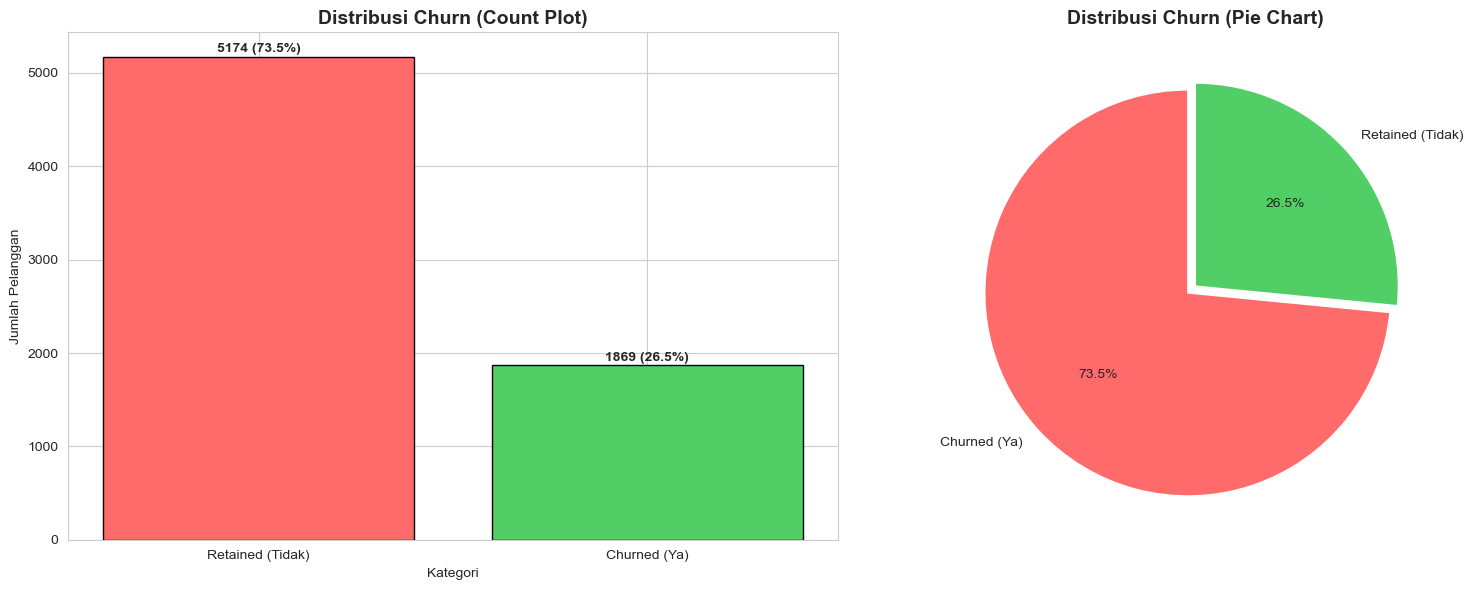


📊 Dataset IMBALANCED: Churn rate = 26.5% (Target ~27%)


In [24]:
# === 3.4 Churn Distribution ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count plot
churn_counts = df['Churn'].value_counts()
colors = ['#ff6b6b', '#51cf66']
axes[0].bar(churn_counts.index.map({'Yes': 'Churned (Ya)', 'No': 'Retained (Tidak)'}), churn_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribusi Churn (Count Plot)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Pelanggan')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v} ({churn_counts.values[i]/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
labels = ['Churned (Ya)', 'Retained (Tidak)']
axes[1].pie(churn_counts.values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05, 0))
axes[1].set_title('Distribusi Churn (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📊 Dataset IMBALANCED: Churn rate = {churn_counts["Yes"]/len(df)*100:.1f}% (Target ~27%)')

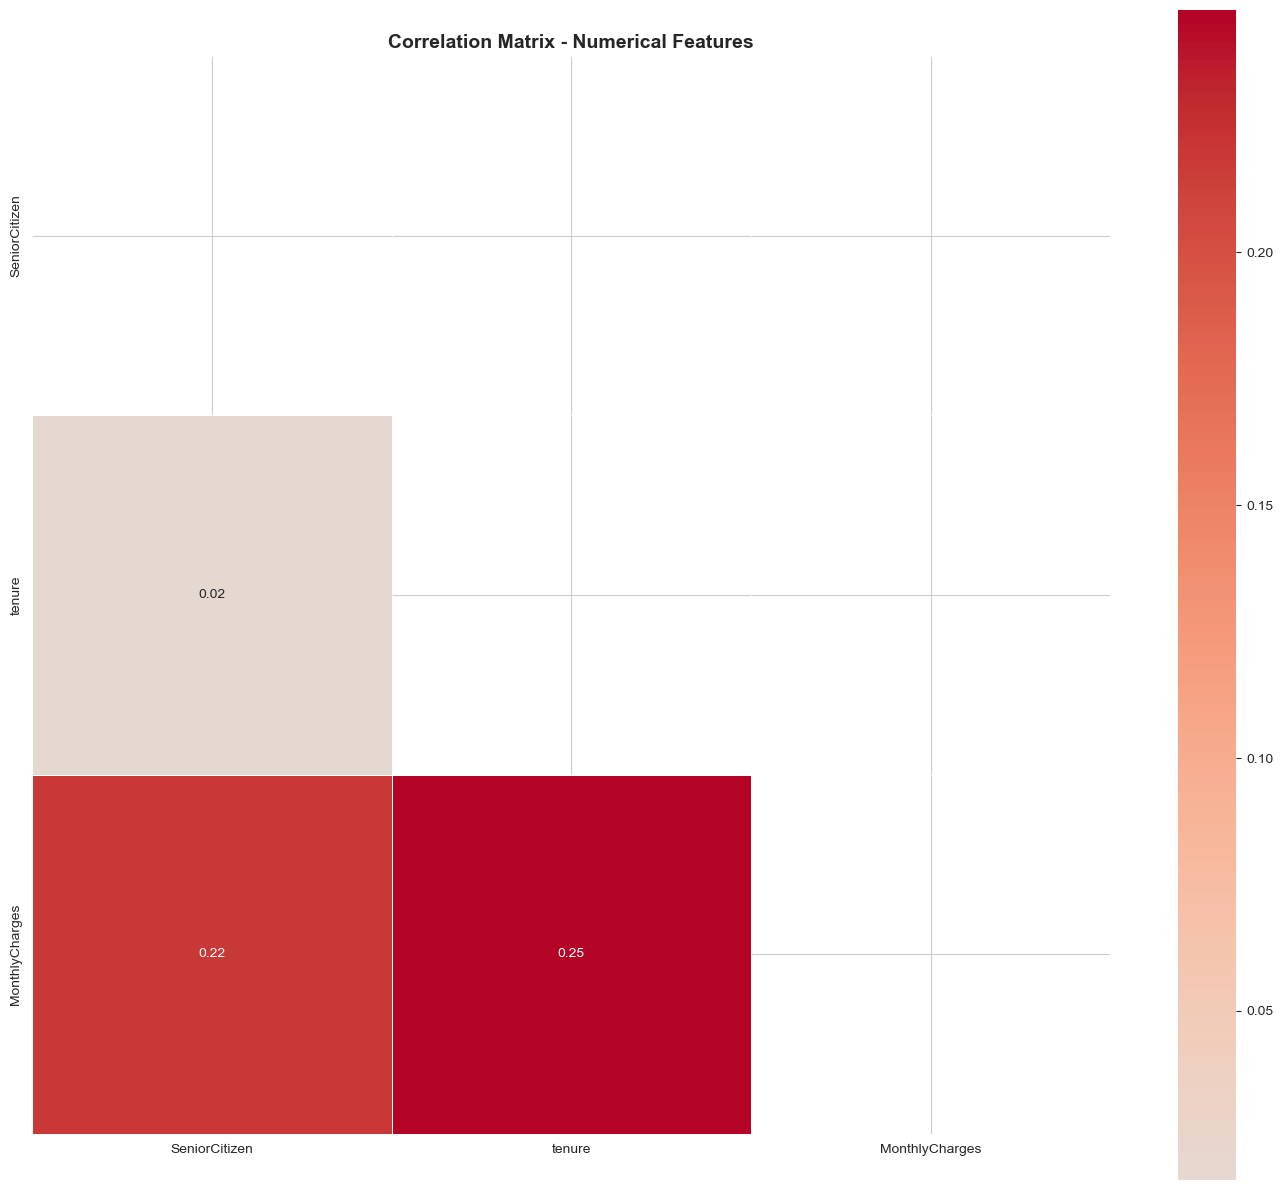

In [25]:
# === 3.5 Correlation Matrix (Numerik Features) ===
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('customerID') if 'customerID' in numerical_cols else None

corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

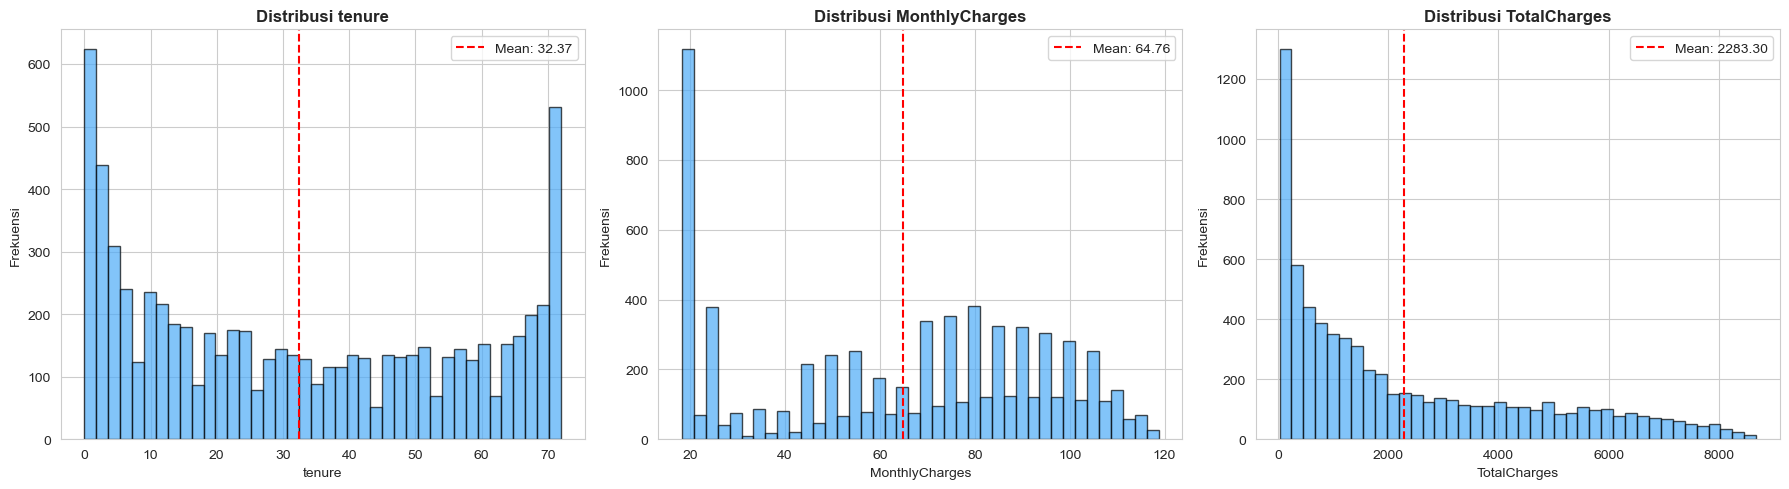

In [26]:
# === 3.6 Histogram Distribusi Feature Numerik ===
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(numerical_features):
    numeric_data = pd.to_numeric(df[feature], errors='coerce')
    axes[idx].hist(numeric_data.dropna(), bins=40, color='#4dabf7', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribusi {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frekuensi')
    mean_val = numeric_data.mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('numerical_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

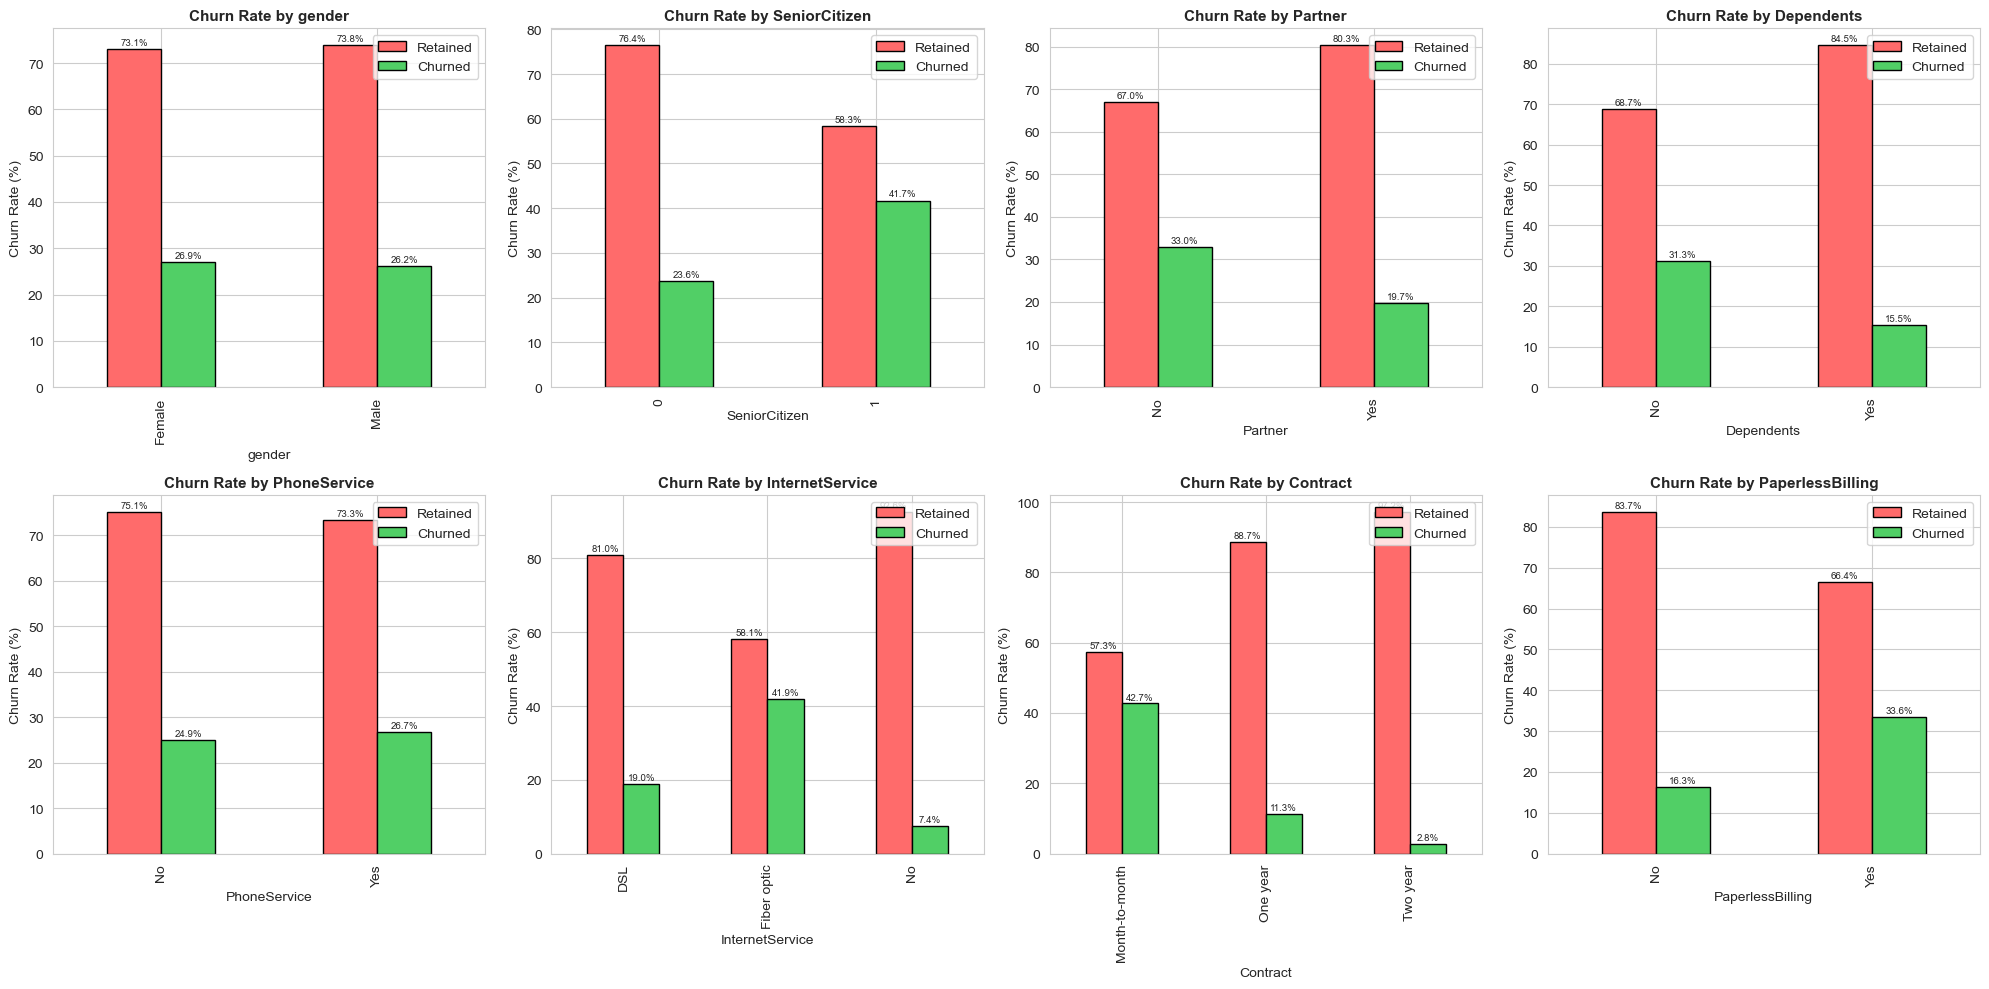

In [27]:
# === 3.7 Churn Rate per Kategori ===
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'Contract', 'PaperlessBilling']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    churn_by_cat = df.groupby(feature)['Churn'].value_counts(normalize=True).unstack() * 100
    churn_by_cat.plot(kind='bar', ax=axes[idx], color=['#ff6b6b', '#51cf66'], edgecolor='black')
    axes[idx].set_title(f'Churn Rate by {feature}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].legend(['Retained', 'Churned'], loc='upper right')
    for p in axes[idx].patches:
        height = p.get_height()
        if height > 0:
            axes[idx].text(p.get_x() + p.get_width()/2., height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## **4. Data Preprocessing**

Melakukan langkah-langkah preprocessing untuk mempersiapkan data agar siap digunakan dalam model machine learning. Termasuk encoding kategorikal, scaling, train-test split, dan feature engineering.

In [28]:
# === 4.1 Handle Missing Values in TotalCharges ===
print('\n🔧 Preprocessing Step 1: Handle Missing Values')
print(f'Before: {df["TotalCharges"].isnull().sum()} missing values')

# TotalCharges yang kosong diubah menjadi string ' ', lalu ke float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
median_tc = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_tc, inplace=True)
print(f'After: {df["TotalCharges"].isnull().sum()} missing values (filled with median: {median_tc:.2f})')
print('✅ Missing values berhasil ditangani.')


🔧 Preprocessing Step 1: Handle Missing Values
Before: 0 missing values
After: 11 missing values (filled with median: 1397.47)
✅ Missing values berhasil ditangani.


In [29]:
# === 4.2 Drop customerID ===
print('\n🔧 Preprocessing Step 2: Remove Unnecessary Columns')
df.drop('customerID', axis=1, inplace=True)
print(f'✅ Dropped customerID. Shape sekarang: {df.shape}')


🔧 Preprocessing Step 2: Remove Unnecessary Columns
✅ Dropped customerID. Shape sekarang: (7043, 20)


In [30]:
# === 4.3 Encode Categorical Features ===
print('\n🔧 Preprocessing Step 3: Encode Categorical Features')

# Encode target variable Churn (Yes=1, No=0)
le_churn = LabelEncoder()
df['Churn'] = le_churn.fit_transform(df['Churn'])
print(f'Churn encoding: {le_churn.classes_}')

# === Map Contract & InternetService BEFORE one-hot (used later in feature engineering) ===
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
internet_map = {'DSL': 0, 'Fiber optic': 1, 'No': 2}
df['ContractType'] = df['Contract'].map(contract_map)
df['InternetType'] = df['InternetService'].map(internet_map)
print('✅ Mapped Contract → ContractType (0=Monthly, 1=Yearly, 2=TwoYear)')
print('✅ Mapped InternetService → InternetType (0=DSL, 1=Fiber, 2=No)')

# Encode kategorikal lainnya
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                   'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                   'PaperlessBilling', 'PaymentMethod']

# Label encoding untuk ordinal/ranked categories
ordinal_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in ordinal_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
print(f'✅ Label encoded {len(ordinal_cols)} columns: {ordinal_cols}')

# One-hot encoding untuk nominal categories dengan banyak kelas
nominal_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
               'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print(f'✅ One-hot encoded {len(nominal_cols)} columns: {nominal_cols}')
print(f'\nShape setelah encoding: {df.shape}')


🔧 Preprocessing Step 3: Encode Categorical Features
Churn encoding: ['No' 'Yes']
✅ Mapped Contract → ContractType (0=Monthly, 1=Yearly, 2=TwoYear)
✅ Mapped InternetService → InternetType (0=DSL, 1=Fiber, 2=No)
✅ Label encoded 5 columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
✅ One-hot encoded 10 columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Shape setelah encoding: (7043, 33)


In [32]:
# === 4.4 Feature Engineering - Advanced Level ===
print('\n🔧 Preprocessing Step 4: Feature Engineering')

# Feature 1: Charges per month (rata-rata pengeluaran per bulan)
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)
print('✅ Created: ChargesPerMonth')

# Feature 2: Tenure bins (kelompok durasi berlangganan)
bins = [0, 12, 24, 48, 72, float('inf')]
labels = ['0-12 (Baru)', '13-24', '25-48', '49-72', '72+ (Lama)']
df['TenureBin'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)
df['TenureBin'] = df['TenureBin'].astype(str)
le_tenure = LabelEncoder()
df['TenureBin'] = le_tenure.fit_transform(df['TenureBin'])
print('✅ Created: TenureBin (binned tenure)')

# Feature 3: Interaction feature - Contract type x Internet service
df['Contract_x_Internet'] = df['ContractType'] * df['InternetType']
print('✅ Created: Contract_x_Internet (interaction feature)')

# Feature 4: Senior citizen interaction
df['SeniorPartner'] = df['SeniorCitizen'] * df['Partner']
print('✅ Created: SeniorPartner (interaction feature)')

print(f'\nShape setelah feature engineering: {df.shape}')


🔧 Preprocessing Step 4: Feature Engineering
✅ Created: ChargesPerMonth
✅ Created: TenureBin (binned tenure)
✅ Created: Contract_x_Internet (interaction feature)
✅ Created: SeniorPartner (interaction feature)

Shape setelah feature engineering: (7043, 37)


In [33]:
# === 4.5 Train-Test Split ===
print('\n🔧 Preprocessing Step 5: Train-Test Split')

# Pisahkan fitur dan target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-test split 80-20 dengan stratify untuk menjaga distribusi class
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape[0]} samples ({y_train.value_counts()[0]} retained, {y_train.value_counts()[1]} churned)')
print(f'Test set:     {X_test.shape[0]} samples ({y_test.value_counts()[0]} retained, {y_test.value_counts()[1]} churned)')
print('✅ Train-test split selesai dengan stratification.')


🔧 Preprocessing Step 5: Train-Test Split
Training set: 5634 samples (4139 retained, 1495 churned)
Test set:     1409 samples (1035 retained, 374 churned)
✅ Train-test split selesai dengan stratification.


In [35]:
# === 4.6 Apply SMOTE for Imbalanced Data (Advanced) ===
print('\n🔧 Preprocessing Step 6: SMOTE - Handling Imbalanced Data')

# Sebelum SMOTE
print(f'\nSebelum SMOTE:')
print(f'Churn distribution: {dict(y_train.value_counts())}')
print(f'Churn rate: {y_train.mean()*100:.1f}%')

# Apply SMOTE
nan_cols = X_train.columns[X_train.isna().any()].tolist()
if nan_cols:
    print(f'⚠️ Columns with NaN found: {nan_cols}')
    X_train = X_train.fillna(0)
    print('✅ NaN filled with 0')
else:
    print('✅ No NaN detected')
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Setelah SMOTE
print(f'\nSetelah SMOTE:')
print(f'Churn distribution: {dict(y_resampled.value_counts())}')
print(f'Churn rate: {y_resampled.mean()*100:.1f}%')
print(f'\n✅ SMOTE berhasil! Samples bertambah dari {len(X_train)} menjadi {len(X_resampled)}.')


🔧 Preprocessing Step 6: SMOTE - Handling Imbalanced Data

Sebelum SMOTE:
Churn distribution: {0: np.int64(4139), 1: np.int64(1495)}
Churn rate: 26.5%
⚠️ Columns with NaN found: ['TotalCharges', 'ChargesPerMonth']
✅ NaN filled with 0

Setelah SMOTE:
Churn distribution: {0: np.int64(4139), 1: np.int64(2069)}
Churn rate: 33.3%

✅ SMOTE berhasil! Samples bertambah dari 5634 menjadi 6208.


In [36]:
# === 4.7 Scaling (StandardScaler) ===
print('\n🔧 Preprocessing Step 7: Feature Scaling')

# Identify numerical and categorical columns for scaler
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth', 'TenureBin', 'ContractType', 'InternetType', 'Contract_x_Internet', 'SeniorPartner']

scaler = StandardScaler()

# Scale training data
X_train_scaled = X_resampled.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train_scaled[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test_scaled[numeric_features])

print('✅ Standard scaling applied to numerical features.')
print(f'\nNumerical features scaled: {numeric_features}')


🔧 Preprocessing Step 7: Feature Scaling
✅ Standard scaling applied to numerical features.

Numerical features scaled: ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth', 'TenureBin', 'ContractType', 'InternetType', 'Contract_x_Internet', 'SeniorPartner']


In [37]:
# === 4.8 Simpan Data yang Sudah Di-preprocess ===
print('\n📦 Menyimpan data hasil preprocessing...')

# Simpan X_train, X_test, y_train, y_test
X_train_scaled.to_csv('data/X_train.csv', index=False)
X_test_scaled.to_csv('data/X_test.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)

print('✅ Data preprocessing selesai!')
print('\n📁 File yang disimpan:')
print('  - data/X_train.csv')
print('  - data/X_test.csv')
print('  - data/y_train.csv')
print('  - data/y_test.csv')


📦 Menyimpan data hasil preprocessing...
✅ Data preprocessing selesai!

📁 File yang disimpan:
  - data/X_train.csv
  - data/X_test.csv
  - data/y_train.csv
  - data/y_test.csv


## **5. Ringkasan Preprocessing**

Langkah-langkah yang telah dilakukan:
1. ✅ Handle missing values di TotalCharges (fillna dengan median)
2. ✅ Drop customerID (tidak informatif)
3. ✅ Encode target Churn (Yes=1, No=0)
4. ✅ Label encoding untuk kategorikal ordinal
5. ✅ One-hot encoding untuk kategorikal nominal
6. ✅ **Feature Engineering** (Advanced): ChargesPerMonth, TenureBin, Contract_x_Internet, SeniorPartner
7. ✅ Train-test split 80-20 dengan stratification
8. ✅ **SMOTE** untuk menangani imbalanced data
9. ✅ Standard scaling pada numerical features
10. ✅ Simpan data hasil preprocessing